In [623]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [624]:
SCALE_HEIGHT = 8000
R = 1.66
GRAV = 9.81
CP = 1004  # J/kg/K
SIGMA = 5.670374419e-8  # W m-2 K-4

In [625]:
def pressure(p0,z):
    return p0*np.exp(-z/SCALE_HEIGHT)

def density(p0,z):
    return p0*np.exp(-z/SCALE_HEIGHT)

def optical_depth(t0,z):
    return t0*np.exp(-z/SCALE_HEIGHT)

def transmittance(t):
    return np.exp(-t*R)

def height(p,p0):
    return -SCALE_HEIGHT*np.log(p/p0)

In [626]:
def black_body_irradiance(temp):
    return SIGMA * temp**4

def transmitted_sfc_flux(temp,t0,p0,p):
    bs = black_body_irradiance(temp)
    return bs*np.exp(-t0*R*(p0-p)/p0)

def flux_atm_up(temp,t0,p0,p):
    # dp = np.diff(p).mean()
    # layer_e = emiss_layer(tau0,p0,dp = dp)
    # ba = black_body_irradiance(temp)*layer_e
    # return ba*np.arange(len(p),0,-1)
    ba = black_body_irradiance(temp)
    return ba*(1 - np.exp(-t0*R*(p0-p)/p0))

def flux_atm_down(temp,t0,p0,p):
    # dp = np.diff(p).mean()
    # layer_e = emiss_layer(tau0,p0,dp = dp)
    # ba = black_body_irradiance(temp)*layer_e
    # return -ba*np.arange(0,len(p))
    ba = black_body_irradiance(temp)
    return ba*(np.exp(-t0*R*p/p0)-1)

def net_lw_rad_flux(temp_sfc,temp_atm,t0,p0,p):
    sfc_up = transmitted_sfc_flux(temp_sfc,t0,p0,p)
    atm_up = flux_atm_up(temp_atm,t0,p0,p)
    atm_down = flux_atm_down(temp_atm,t0,p0,p)
    return sfc_up + atm_up + atm_down

def flux_convergence(temp_sfc,temp_atm,t0,p0,p):
    b_sfc = black_body_irradiance(temp_sfc)
    b_atm = black_body_irradiance(temp_atm)
    # return b_sfc*t0*R/p0*np.exp(-t0*R/p0*(p0-p)) - b_atm*t0*R/p0*np.exp(-t0*R/p0*(p0-p)) + b_atm*t0*R/p0*np.exp(-t0*R*p/p0)
    ### NOT RIGHT ### just taking gradient of prior function instead
    return -(t0*R/p0*(b_sfc*np.exp(-t0*R/p0*(p0-p)) - b_atm*(np.exp(-t0*R/p0*(p0-p)) - np.exp(-t0*R*p/p0))))

def flux_atm_up_noniso(temp_profile, t0, p0, p):
    """Upward atmospheric flux at each level p for non-isothermal atmosphere."""
    n = len(p)
    kernel_factor = t0 * R / p0
    F_up = np.zeros(n)
    for i, pi in enumerate(p):
        # Integrate contributions from layers below pi (p' > pi)
        p_below = p[i:]          # pressure levels below level i (higher pressure)
        T_below = temp_profile[i:]
        B_below = black_body_irradiance(T_below)
        transmittance = np.exp(-kernel_factor * (p_below - pi))
        F_up[i] = np.trapezoid(B_below * kernel_factor * transmittance, p_below)
    return F_up

def flux_atm_down_noniso(temp_profile, t0, p0, p):
    """Downward atmospheric flux at each level p (negative = downward)."""
    n = len(p)
    kernel_factor = t0 * R / p0
    F_down = np.zeros(n)
    for i, pi in enumerate(p):
        # Integrate contributions from layers above pi (p' < pi)
        p_above = p[:i+1]        # pressure levels above level i (lower pressure)
        T_above = temp_profile[:i+1]
        B_above = black_body_irradiance(T_above)
        transmittance = np.exp(-kernel_factor * (pi - p_above))
        F_down[i] = -np.trapezoid(B_above * kernel_factor * transmittance, p_above)
    return F_down

def net_lw_rad_flux_noniso(temp_sfc, temp_profile, t0, p0, p):
    sfc_up  = transmitted_sfc_flux(temp_sfc, t0, p0, p)
    atm_up  = flux_atm_up_noniso(temp_profile, t0, p0, p)
    atm_down = flux_atm_down_noniso(temp_profile, t0, p0, p)
    return sfc_up + atm_up + atm_down


In [627]:
# def temp_atm(s, z):
#     return (s - GRAV*z)/CP

# # def ds_dt(dF_dt):
# #     return -GRAV * dF_dt

In [628]:
tau0 = 1.42
Fsw = -280

Tsfc = 308.2
S0_4 = -400
alpha_p = 0.3
Te = 265.1
emiss = 0.905
tstar = 1 - emiss
Tatm = 259.2

rho = 1000 # kg/m3
h = 1 # m
p0 = 100000 # pa
cp_water = 4184 # J⋅kg−1⋅K−1

In [629]:
# Use coarser grid to keep loop fast (p is 100k points — very slow)
p_coarse = np.linspace(p0 / 100, p0, 100)      # 500-level grid is much faster
dp = np.diff(p_coarse).mean()
z = height(p = p_coarse,p0 = p0)

p_mid = p_coarse - dp/2
z_mid = height(p = p_mid,p0 = p0)

In [630]:
dt = 60*60
n_iter = 10000
tol = 0.1 

In [631]:
gamma_d = 0.00977

rho_2m = 1.2
Csh = 10**-3
v0 = 5

In [632]:
sfc_temp = Tsfc
atm_profile = np.ones(len(p_coarse)) * Tatm
dse_profile = CP * atm_profile + GRAV*height(p = p_coarse, p0 = p0)

for i in range(n_iter):

    F = net_lw_rad_flux_noniso(sfc_temp, atm_profile, tau0, p0, p_coarse)
    dFdp = -np.gradient(F, p_coarse)
    dTdt = -GRAV / CP * dFdp               # K/s
    delta_T = dTdt * dt
    atm_profile = atm_profile + delta_T

    dsdt = -GRAV * dFdp
    delta_s = dsdt * dt
    dse_profile = dse_profile + delta_s

    # surface temp change
    dTsdt = -(Fsw + F[-1])/(cp_water*rho*h)
    delta_Ts = dTsdt * dt
    sfc_temp = sfc_temp + delta_Ts

    net_flux_toa = Fsw + F[0]
    net_flux_sfc = Fsw + F[-1]

    # if np.max(np.abs(delta_T)) < tol:
    if (np.abs(net_flux_toa) < tol) and (np.abs(net_flux_sfc) < tol):
        print(f"Converged at iteration {i}")
        break


Converged at iteration 5814


In [633]:

# Ta_rad_z = (dse_profile - z*GRAV)/CP

Ta_rad_z = atm_profile
s_rad_z = dse_profile
Ts_rad = sfc_temp

In [634]:
Ts_rad

np.float64(321.6059070778802)

Text(0.5, 1.0, 'Radiative Equilibrium Atmospheric Temperature')

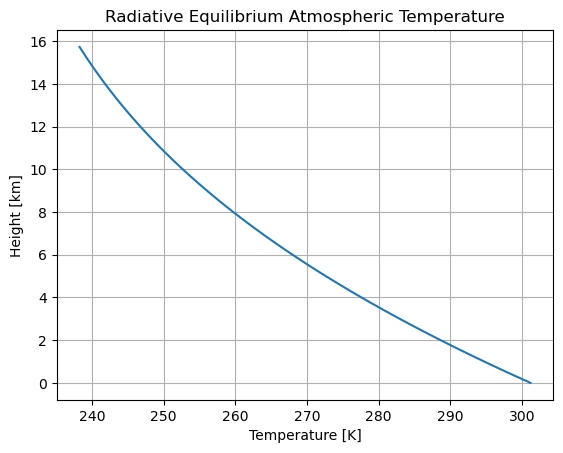

In [635]:
plt.grid()
plt.plot(Ta_rad_z[z<16000],z[z < 16000]/1000)
# plt.plot(atm_profile[z<16000],z[z < 16000]/1000)
plt.xlabel('Temperature [K]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium Atmospheric Temperature')

Text(0.5, 1.0, 'Radiative Equilibrium Atmospheric Dry Static Energy')

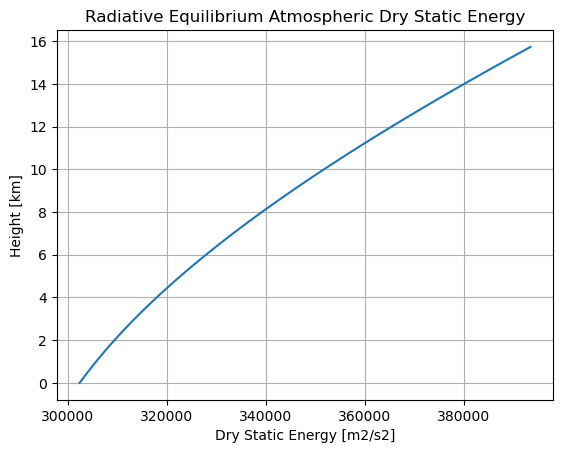

In [636]:
plt.grid()
plt.plot(dse_profile[z<16000],z[z < 16000]/1000)
plt.xlabel('Dry Static Energy [m2/s2]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium Atmospheric Dry Static Energy')

In [637]:
dp/p0

np.float64(0.01)

In [638]:
T2m_rad = Ta_rad_z[-1] + (z_mid[-1] - 2)*gamma_d
T2m_rad

np.float64(301.53483661767854)

In [639]:
Ts_rad - T2m_rad

np.float64(20.071070460201668)

In [640]:
# sensible heat flux
Fsh = CP * rho_2m * Csh * v0 * (Ts_rad - T2m_rad)
Fsh

np.float64(120.90812845225483)

In [641]:
dTa1dt = (GRAV / CP)* (Fsh/dp)
dTa1dt * (60*60*24)

np.float64(102.07150910963743)

In [642]:
dp

np.float64(1000.0)

In [643]:
###### ADD IN SENSIBLE HEAT FLUX #########

z = height(p = p_coarse,p0 = p0)

sfc_temp = Tsfc
atm_profile = np.ones(len(p_coarse)) * Tatm
dse_profile = CP * atm_profile + GRAV*height(p = p_coarse, p0 = p0)

for i in range(n_iter):

    # net rad flux (LW)
    F = net_lw_rad_flux_noniso(sfc_temp, atm_profile, tau0, p0, p_coarse)
    # radiative divergence
    dFdp = -np.gradient(F, p_coarse)
    # sensible heat
    T2m = atm_profile[-1] + (z_mid[-1] - 2)*gamma_d
    Fsh = CP * rho_2m * Csh * v0 * (sfc_temp - T2m)

    # update dry static energy from radiation
    dsdt = -GRAV * dFdp
    dse_profile = dse_profile + dsdt * dt

    # dry convective adjustment with sensible heat flux spread over N layers
    dse_old = dse_profile.copy()
    dSH_single = Fsh * dt * GRAV / dp
    N = 1
    unstable = True
    while unstable and N <= len(dse_profile):
        dSH_N = dSH_single / N
        mixed_avg = dse_old[-N:].mean()
        dse_trial = dse_old.copy()
        dse_trial[-N:] = mixed_avg + dSH_N
        if np.any(np.diff(dse_trial) > 0):
            N += 1
        else:
            unstable = False
    dse_profile = dse_trial

    atm_profile = (dse_profile - z*GRAV)/CP

    # surface temp change
    dTsdt = -(Fsw + F[-1] + Fsh)/(cp_water*rho*h)
    delta_Ts = dTsdt * dt
    sfc_temp = sfc_temp + delta_Ts

    net_flux_toa = Fsw + F[0]
    net_flux_sfc = Fsw + F[-1] + Fsh

    if (np.abs(net_flux_toa) < tol) and (np.abs(net_flux_sfc) < tol):
        print(f"Converged at iteration {i}")
        break


In [644]:
sfc_temp

np.float64(317.7400054963676)

In [645]:
Ta_rad_dry_z = atm_profile
s_rad_dry_z = dse_profile
T2m_rad_dry = T2m
Ts_rad_dry = sfc_temp

(0.0, 16.0)

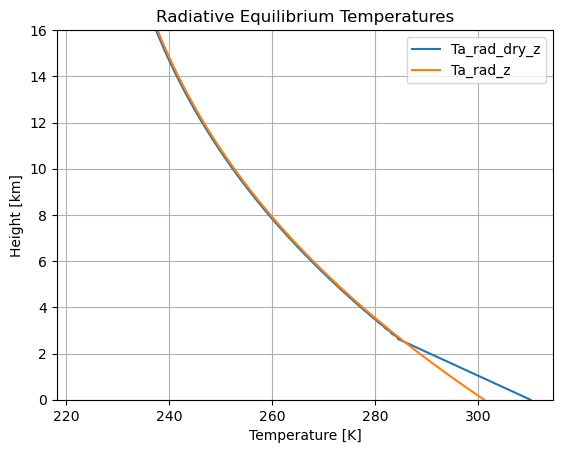

In [646]:
plt.plot(Ta_rad_dry_z,z/1000,label='Ta_rad_dry_z')
plt.plot(Ta_rad_z,z/1000,label='Ta_rad_z')
plt.grid()
plt.xlabel('Temperature [K]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium Temperatures')
plt.grid(True)
plt.legend()
plt.ylim(0,16)

(300.0, 400.0)

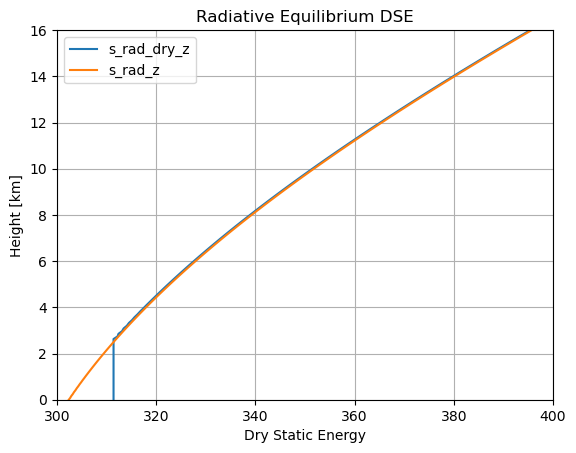

In [647]:
plt.plot(s_rad_dry_z/1000,z/1000,label='s_rad_dry_z')
plt.plot(s_rad_z/1000,z/1000,label='s_rad_z')
plt.grid()
plt.xlabel('Dry Static Energy')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium DSE')
plt.grid(True)
plt.legend()
plt.ylim(0,16)
plt.xlim(300,400)

In [648]:
T2m_rad_dry

np.float64(310.5258445925889)

In [649]:
Ts_rad_dry - T2m_rad_dry

np.float64(7.214160903778691)

In [650]:
Fsh

np.float64(43.45810409194806)

## Q4

In [651]:
LV = 2.25*10**6 #J/kg
RV = 461 #J kg−1K−1

In [652]:
def saturation_vapor_pressure(Ta):
    eref = 611
    Tref = 273
    return eref * np.exp((LV/RV)*((1/Tref) - (1/Ta)))

def saturation_mixing_ratio(Ta,p):
    es = saturation_vapor_pressure(Ta)
    return 0.622*es/(p-es)

def mixing_ratio(Ta,p,rel_hum):
    return rel_hum * saturation_mixing_ratio(Ta,p)



In [653]:
Ts_rad_dry

np.float64(317.7400054963676)

In [654]:
T2m_rad_dry

np.float64(310.5258445925889)

In [655]:
rel_hum_2m = 0.8
Clh = 10**-3
p2m = p0*np.exp(-2/SCALE_HEIGHT)

q_sfc = mixing_ratio(Ta = Ts_rad_dry, p = p0, rel_hum = 1)
q_2m = mixing_ratio(Ta = T2m_rad_dry, p = p2m, rel_hum = rel_hum_2m)
Flh = LV * rho_2m * Clh * v0 * (q_sfc - q_2m)

In [656]:
Flh

np.float64(311.97530841398884)

In [657]:
((GRAV / CP) * (Flh / dp))*60*60*24

np.float64(263.3717926362175)

In [658]:
q_sat_atm = saturation_mixing_ratio(Ta_rad_dry_z, p_coarse)
h_sat_rad_dry_z = CP * Ta_rad_dry_z + GRAV * z + LV * q_sat_atm

Text(0.5, 1.0, 'Saturated MSE for Dry Radiative Convective Equilibrium')

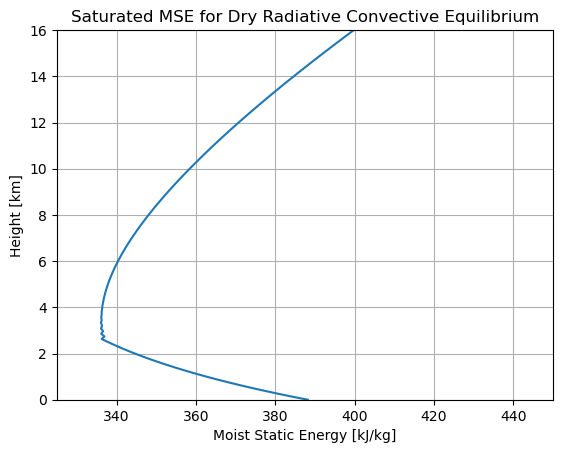

In [659]:
plt.plot(h_sat_rad_dry_z/1000,z/1000)
plt.ylim(0,16)
plt.xlim(325,450)
plt.grid()
plt.xlabel('Moist Static Energy [kJ/kg]')
plt.ylabel('Height [km]')
plt.title("Saturated MSE for Dry Radiative Convective Equilibrium")

# Q5

In [660]:
###### ADD IN LATENT HEAT FLUX + MOIST CONVECTIVE ADJUSTMENT #########

def q_sat_capped(T, p):
    """Saturation mixing ratio with physical caps per Q5 constraints."""
    es = saturation_vapor_pressure(T)
    es = np.minimum(es, 0.99 * p)                      # e_sat cannot exceed p
    q  = 0.622 * es / (p - es)
    q  = np.minimum(q, 1.0)                            # cap at 1 kg/kg
    q  = np.where(p < 10000, np.minimum(q, 0.0015), q) # stratospheric cap
    return q

def h_mse(T, p, z):
    """Saturated moist static energy: h = cp*T + g*z + Lv*q_sat"""
    return CP * T + GRAV * z + LV * q_sat_capped(T, p)

def T_from_h(h_target, p, z):
    """Invert h = cp*T + g*z + Lv*q_sat(T,p) via vectorized bisection (60 iterations)."""
    T_lo = np.full_like(h_target, 150.0)
    T_hi = np.full_like(h_target, 500.0)
    for _ in range(60):
        T_mid = 0.5 * (T_lo + T_hi)
        h_mid = h_mse(T_mid, p, z)
        below = h_mid < h_target
        T_lo[ below] = T_mid[ below]
        T_hi[~below] = T_mid[~below]
    return 0.5 * (T_lo + T_hi)

z = height(p=p_coarse, p0=p0)

# Initialize from Q3 radiative-dry-convective equilibrium
sfc_temp    = Ts_rad_dry
atm_profile = Ta_rad_dry_z.copy()
mse_profile = h_mse(atm_profile, p_coarse, z)

for i in range(n_iter):

    # net LW flux
    F    = net_lw_rad_flux_noniso(sfc_temp, atm_profile, tau0, p0, p_coarse)
    dFdp = -np.gradient(F, p_coarse)

    # 2m temperature and mixing ratios
    T2m   = atm_profile[-1] + (z_mid[-1] - 2) * gamma_d
    q_sfc = q_sat_capped(sfc_temp, p0)
    q_2m  = rel_hum_2m * q_sat_capped(T2m, p2m)

    # sensible and latent heat fluxes
    Fsh = CP * rho_2m * Csh * v0 * (sfc_temp - T2m)
    Flh = LV * rho_2m * Clh * v0 * (q_sfc - q_2m)

    # update moist static energy from radiative divergence
    mse_profile = mse_profile + (-GRAV * dFdp) * dt

    # moist convective adjustment with Fsh+Flh spread over N layers
    mse_old = mse_profile.copy()
    dSH_LH_single = (Fsh + Flh) * dt * GRAV / dp
    N = 1
    unstable = True
    while unstable and N <= len(mse_profile):
        dSH_LH_N = dSH_LH_single / N
        mixed_avg = mse_old[-N:].mean()
        mse_trial = mse_old.copy()
        mse_trial[-N:] = mixed_avg + dSH_LH_N
        if np.any(np.diff(mse_trial) > 0):
            N += 1
        else:
            unstable = False
    mse_profile = mse_trial

    # recover temperature from moist static energy (numerical inversion)
    atm_profile = T_from_h(mse_profile, p_coarse, z)

    # re-derive mse from recovered T for consistency
    mse_profile = h_mse(atm_profile, p_coarse, z)

    # surface temperature update
    dTsdt    = -(Fsw + F[-1] + Fsh + Flh) / (cp_water * rho * h)
    sfc_temp = sfc_temp + dTsdt * dt

    net_flux_toa = Fsw + F[0]
    net_flux_sfc = Fsw + F[-1] + Fsh + Flh

    if (np.abs(net_flux_toa) < tol) and (np.abs(net_flux_sfc) < tol):
        print(f"Converged at iteration {i}")
        break

# save results
Ta_rad_conv_z    = atm_profile
s_rad_conv_z     = CP * atm_profile + GRAV * z
h_sat_rad_conv_z = mse_profile
Ts_rad_conv      = sfc_temp
T2m_rad_conv     = T2m
n_mix_conv       = n_mix


In [661]:
Ts_rad_conv

np.float64(305.82475849302125)

In [662]:
T2m_rad_conv

np.float64(303.06294319796706)

In [663]:
Ts_rad_conv - T2m_rad_conv

np.float64(2.761815295054191)

(0.0, 16.0)

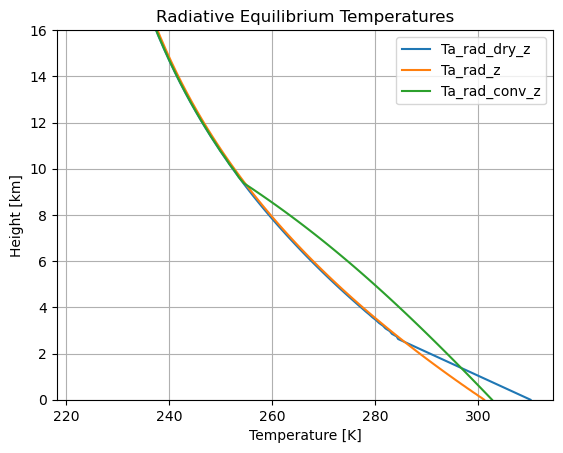

In [664]:
plt.plot(Ta_rad_dry_z,z/1000,label='Ta_rad_dry_z')
plt.plot(Ta_rad_z,z/1000,label='Ta_rad_z')
plt.plot(Ta_rad_conv_z,z/1000,label='Ta_rad_conv_z')
plt.grid()
plt.xlabel('Temperature [K]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium Temperatures')
plt.grid(True)
plt.legend()
plt.ylim(0,16)

(300.0, 400.0)

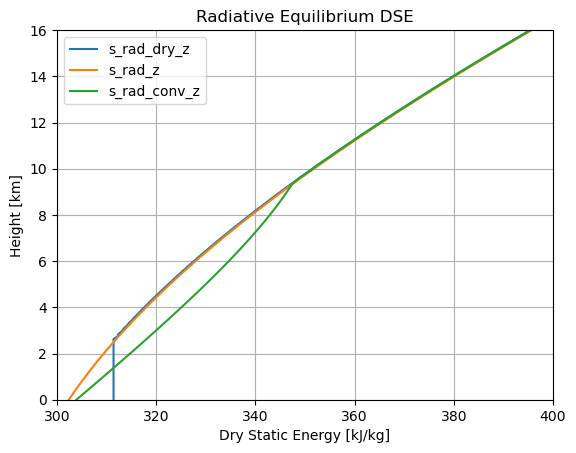

In [665]:
plt.plot(s_rad_dry_z/1000,z/1000,label='s_rad_dry_z')
plt.plot(s_rad_z/1000,z/1000,label='s_rad_z')
plt.plot(s_rad_conv_z/1000,z/1000,label='s_rad_conv_z')
plt.grid()
plt.xlabel('Dry Static Energy [kJ/kg]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium DSE')
plt.grid(True)
plt.legend()
plt.ylim(0,16)
plt.xlim(300,400)

(325.0, 400.0)

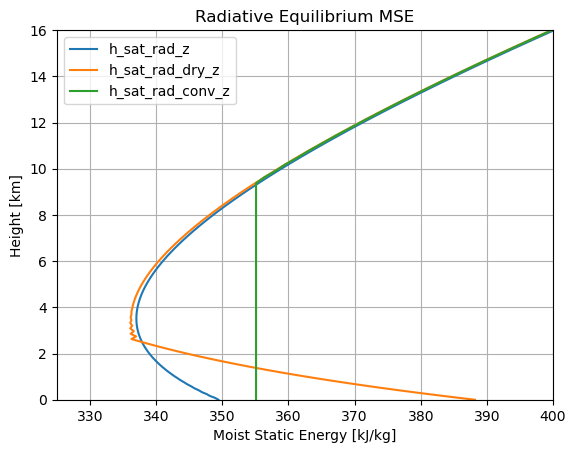

In [666]:

q_sat_rad_z = saturation_mixing_ratio(Ta_rad_z, p_coarse)
h_sat_rad_z = CP * Ta_rad_z + GRAV * z + LV * q_sat_rad_z

plt.plot(h_sat_rad_z/1000,z/1000,label='h_sat_rad_z')
plt.plot(h_sat_rad_dry_z/1000,z/1000,label='h_sat_rad_dry_z')
plt.plot(h_sat_rad_conv_z/1000,z/1000,label='h_sat_rad_conv_z')
plt.grid()
plt.xlabel('Moist Static Energy [kJ/kg]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium MSE')
plt.grid(True)
plt.legend()
plt.ylim(0,16)
plt.xlim(325,400)

In [667]:
# z[np.gradient(h_sat_rad_dry_z) > 0]
Ta_rad_dry_z[np.gradient(h_sat_rad_dry_z) > 0]

array([280.76755007, 281.52770659, 282.03042286, 282.85790419,
       283.26453408, 284.17974172, 284.4753185 , 285.55350567,
       286.61702317, 287.66626484, 288.70160886, 289.72341858,
       290.7320433 , 291.72781894, 292.71106877, 293.68210399,
       294.64122438, 295.58871878, 296.52486566, 297.44993363,
       298.36418183, 299.26786046, 300.16121111, 301.04446718,
       301.91785426, 302.78159046, 303.63588673, 304.48094719,
       305.31696939, 306.14414463, 306.96265819, 307.77268959,
       308.57441283, 309.3679966 , 310.15360453])

In [668]:
# z[np.abs(np.gradient(h_sat_rad_conv_z)) < 0.01]
Ta_rad_conv_z[np.abs(np.gradient(h_sat_rad_conv_z)) < 0.01]

array([256.27595218, 257.89923251, 259.44146893, 260.90947673,
       262.3093732 , 263.64664976, 264.92623912, 266.15257655,
       267.32965525, 268.46107594, 269.55009092, 270.59964309,
       271.61240044, 272.59078638, 273.5370065 , 274.4530721 ,
       275.34082087, 276.20193513, 277.03795791, 277.85030712,
       278.64028808, 279.4091046 , 280.15786883, 280.88760993,
       281.59928186, 282.2937703 , 282.97189875, 283.6344341 ,
       284.28209154, 284.91553898, 285.53540101, 286.14226251,
       286.73667185, 287.31914382, 287.89016224, 288.45018239,
       288.99963313, 289.5389189 , 290.06842151, 290.58850176,
       291.09950093, 291.60174218, 292.09553174, 292.58116012,
       293.05890311, 293.52902277, 293.9917683 , 294.44737691,
       294.89607449, 295.33807639, 295.77358801, 296.20280544,
       296.62591597, 297.04309864, 297.4545247 , 297.86035803,
       298.26075563, 298.6558679 , 299.04583907, 299.43080752,
       299.81090608, 300.18626232, 300.55699884, 300.92

# Q6

In [669]:
Fsw + F[-1]

np.float64(-130.49187630015524)

In [670]:
Fsh

np.float64(16.637176741785904)

In [671]:
Flh

np.float64(113.85497050808368)

In [672]:
(GRAV/CP)*Flh/dp * 60*60*24

np.float64(96.11718259275258)

In [673]:
(GRAV * 113)/(CP * p0) * 60 * 60 * 24

0.9539541035856574

(0.0, 16.0)

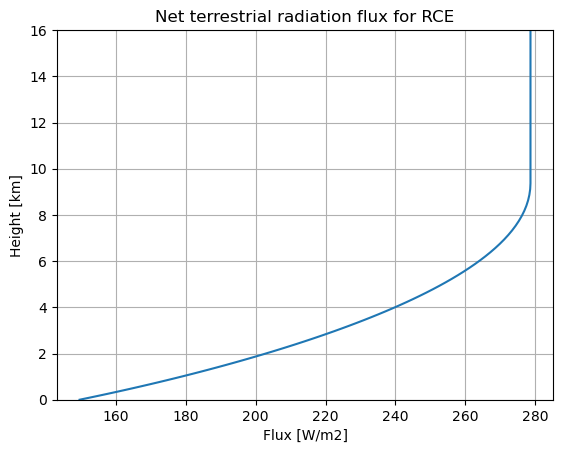

In [674]:

plt.plot(F,z/1000)
plt.grid()
plt.xlabel('Flux [W/m2]')
plt.ylabel('Height [km]')
plt.title('Net terrestrial radiation flux for RCE')
plt.grid(True)
# plt.legend()
plt.ylim(0,16)
# plt.xlim(300,400)

(0.0, 16.0)

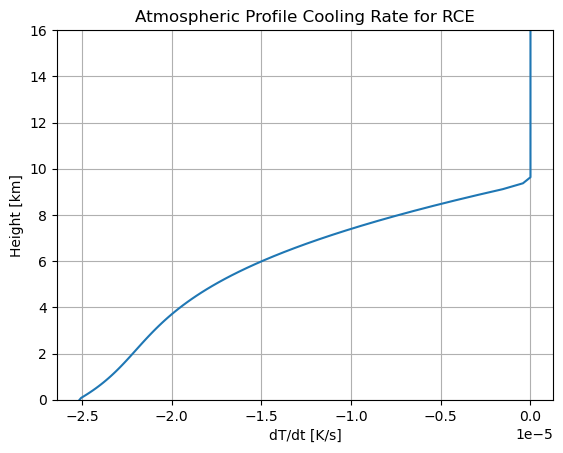

In [675]:


# plt.plot(h_sat_rad_z/1000,z/1000,label='h_sat_rad_z')
# plt.plot(h_sat_rad_dry_z/1000,z/1000,label='h_sat_rad_dry_z')

plt.plot((GRAV/CP)*np.gradient(F,p_coarse),z/1000)
plt.grid()
plt.xlabel('dT/dt [K/s]')
plt.ylabel('Height [km]')
plt.title('Atmospheric Profile Cooling Rate for RCE')
plt.grid(True)
# plt.legend()
plt.ylim(0,16)
# plt.xlim(300,400)

In [676]:
(GRAV/CP)*np.gradient(F,p_coarse)[z < 16000].mean() * 60*60*24

np.float64(-1.266258468967587)

# Q7

(0.0, 16.0)

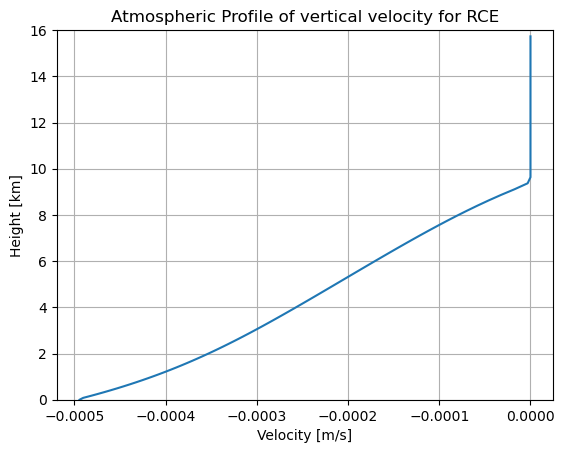

In [677]:
# rho_2m
w = ((-np.gradient(F,p_coarse)[z < 16000])/np.gradient(s_rad_conv_z,p_coarse)[z < 16000])/(rho_2m*GRAV)

plt.plot(w,z[z < 16000]/1000)
plt.grid()
plt.xlabel('Velocity [m/s]')
plt.ylabel('Height [km]')
plt.title('Atmospheric Profile of vertical velocity for RCE')
plt.grid(True)
# plt.legend()
plt.ylim(0,16)
# plt.xlim(300,400)

# Q8

In [678]:
(Flh / (rho * LV)) * 1000 * 60*60*24

np.float64(4.372030867510414)

In [679]:
qavg = q_sat_capped(Ta_rad_conv_z, p_coarse).mean()
qavg * p0 / (GRAV * rho) * 1000

np.float64(107.27768808070044)

# Q9

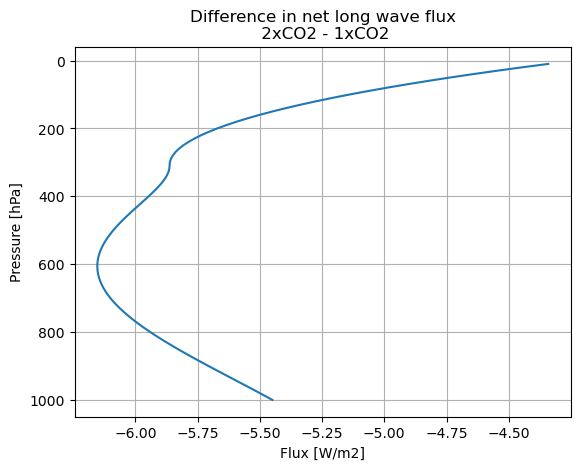

In [680]:
tau_2xco2 = 1.48
F_1xco2 = F
F_2xco2 = net_lw_rad_flux_noniso(Ts_rad_conv, Ta_rad_conv_z, tau_2xco2, p0, p_coarse)

plt.plot(F_2xco2 - F_1xco2,p_coarse/100)
# plt.plot(,p_coarse/100,label='2xCO2')
plt.ylabel('Pressure [hPa]')
plt.xlabel('Flux [W/m2]')
plt.title('Difference in net long wave flux\n 2xCO2 - 1xCO2')
plt.grid()
ax = plt.gca()
ax.yaxis.set_inverted(True)

In [681]:
(F_2xco2 - F_1xco2)[0]

np.float64(-4.341418748687204)

In [682]:
###### ADD IN LATENT HEAT FLUX + MOIST CONVECTIVE ADJUSTMENT #########

# Initialize from Q5 radiative-moist-convective equilibrium
sfc_temp    = Ts_rad_conv
atm_profile = Ta_rad_conv_z.copy()
mse_profile = h_sat_rad_conv_z

for i in range(n_iter):

    # net LW flux
    F    = net_lw_rad_flux_noniso(sfc_temp, atm_profile, tau_2xco2, p0, p_coarse)
    dFdp = -np.gradient(F, p_coarse)

    # 2m temperature and mixing ratios
    T2m   = atm_profile[-1] + (z_mid[-1] - 2) * gamma_d
    q_sfc = q_sat_capped(sfc_temp, p0)
    q_2m  = rel_hum_2m * q_sat_capped(T2m, p2m)

    # sensible and latent heat fluxes
    Fsh = CP * rho_2m * Csh * v0 * (sfc_temp - T2m)
    Flh = LV * rho_2m * Clh * v0 * (q_sfc - q_2m)

    # update moist static energy from radiative divergence
    mse_profile = mse_profile + (-GRAV * dFdp) * dt

    # moist convective adjustment with Fsh+Flh spread over N layers
    mse_old = mse_profile.copy()
    dSH_LH_single = (Fsh + Flh) * dt * GRAV / dp
    N = 1
    unstable = True
    while unstable and N <= len(mse_profile):
        dSH_LH_N = dSH_LH_single / N
        mixed_avg = mse_old[-N:].mean()
        mse_trial = mse_old.copy()
        mse_trial[-N:] = mixed_avg + dSH_LH_N
        if np.any(np.diff(mse_trial) > 0):
            N += 1
        else:
            unstable = False
    mse_profile = mse_trial

    # recover temperature from moist static energy (numerical inversion)
    atm_profile = T_from_h(mse_profile, p_coarse, z)

    # re-derive mse from recovered T for consistency
    mse_profile = h_mse(atm_profile, p_coarse, z)

    # surface temperature update
    dTsdt    = -(Fsw + F[-1] + Fsh + Flh) / (cp_water * rho * h)
    sfc_temp = sfc_temp + dTsdt * dt

    net_flux_toa = Fsw + F[0]
    net_flux_sfc = Fsw + F[-1] + Fsh + Flh

    if (np.abs(net_flux_toa) < tol) and (np.abs(net_flux_sfc) < tol):
        print(f"Converged at iteration {i}")
        break

# save results
Ta_rad_conv_z_2xco2    = atm_profile
s_rad_conv_z_2xco2     = CP * atm_profile + GRAV * z
h_sat_rad_conv_z_2xco2 = mse_profile
Ts_rad_conv_2xco2      = sfc_temp
T2m_rad_conv_2xco2     = T2m
n_mix_conv_2xco2       = n_mix


In [683]:
(Ts_rad_conv_2xco2 - Ts_rad_conv) / (-(F_2xco2 - F_1xco2)[0])

np.float64(0.2129672224845054)

In [684]:
Ts_rad_conv_2xco2 - T2m_rad_conv_2xco2

np.float64(2.7279137890607217)

Text(0.5, 1.0, 'Change in RCE temperature\n2xCO2 - 1xCO2')

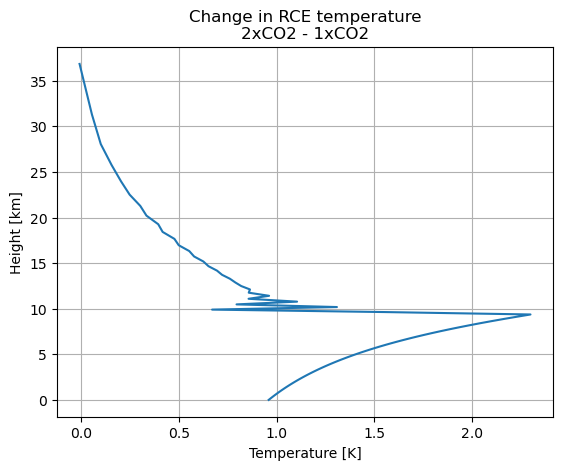

In [685]:
delta_T = Ta_rad_conv_z_2xco2 - Ta_rad_conv_z
plt.plot(delta_T[z < 40000],z[z<40000]/1000)
plt.xlabel('Temperature [K]')
plt.ylabel('Height [km]')
plt.grid()
plt.title('Change in RCE temperature\n2xCO2 - 1xCO2')

In [686]:
# z[np.abs(np.gradient(h_sat_rad_conv_z_2xco2)) < 0.01]
Ta_rad_conv_z_2xco2[np.abs(np.gradient(h_sat_rad_conv_z_2xco2)) < 0.01]

array([256.86225964, 258.50267189, 260.0588882 , 261.5382784 ,
       262.94741391, 264.29215812, 265.57774859, 266.8088708 ,
       267.98972368, 269.12407744, 270.21532434, 271.26652312,
       272.28043791, 273.25957209, 274.20619794, 275.12238248,
       276.01001012, 276.8708024 , 277.70633536, 278.51805474,
       279.30728938, 280.075263  , 280.82310462, 281.55185772,
       282.26248845, 282.95589283, 283.63290319, 284.29429396,
       284.94078671, 285.57305482, 286.19172755, 286.79739374,
       287.39060516, 287.97187945, 288.5417029 , 289.10053284,
       289.64879988, 290.18690995, 290.71524607, 291.23417009,
       291.74402413, 292.24513205, 292.73780066, 293.22232092,
       293.69896896, 294.16800713, 294.62968482, 295.08423937,
       295.53189675, 295.97287234, 296.40737155, 296.83559041,
       297.25771614, 297.6739277 , 298.0843962 , 298.48928541,
       298.88875217, 299.28294671, 299.6720131 , 300.05608954,
       300.43530866, 300.80979785, 301.17967951, 301.54

# Q10

In [687]:
net_flux_sfc = Fsw + F[-1] + Fsh + Flh

In [688]:
net_solar_terr_rad_2xco2 = Fsw + F[-1]
net_solar_terr_rad_2xco2

np.float64(-135.50321954369775)

In [689]:
(Fsh - 16.7)/16.7

np.float64(-0.01599147448432437)

In [690]:
(Flh - 113.8)/113.8

np.float64(0.04629430627282004)

In [691]:
(GRAV/CP)*(Flh/dp)*60*60*24

np.float64(100.51830602805558)

In [692]:
(100.3-95.9)/95.9

0.045881126173096885

In [693]:
(GRAV / CP)*np.gradient(F,p_coarse).mean()*60*60*24

np.float64(-1.1437436918017263)

In [694]:
(-1.14+1.26)/-1.26

-0.09523809523809532

# Q11

In [695]:
(Flh / (rho * LV))*1000*60*60*24

np.float64(4.572222414867722)

In [696]:
(4.57 - 4.37)/4.37

0.04576659038901606

In [697]:
qavg_2xco2 = q_sat_capped(Ta_rad_conv_z_2xco2, p_coarse).mean()
qavg_2xco2 * p0 / (GRAV * rho) * 1000

np.float64(115.23423747215121)

In [698]:
(122.3 - 113.8)/113.8

0.07469244288224956